# 4.4 & 4.5 ラプラス近似とベイズロジスティック回帰 (Laplace Approximation & Bayesian Logistic Regression)

本ノートブックでは、解析的に積分できない事後分布を取り扱う強力な決定論的近似法である**ラプラス近似 (The Laplace Approximation)** と、それを適用した**ベイズロジスティック回帰 (Bayesian Logistic Regression)** を学びます。
最頻値周辺でのガウス近似（**PRML Figure 4.14**）、モデル比較と BIC の導出、パラメータ事後分布のガウス近似、およびプロビット近似を用いた畳み込み積分による予測分布の導出と**不確実性による決定境界の軟化（PRML Figure 4.15）**を完全再現します。

## 4.4 ラプラス近似 (The Laplace Approximation, PRML Figure 4.14)

連続変数 $\mathbf{z}$ 上の確率密度 $p(\mathbf{z}) = \frac{1}{Z} f(\mathbf{z})$ を考えます（$Z = \int f(\mathbf{z}) d\mathbf{z}$ は未知の規格化定数）。
ラプラス近似の目的は、最頻値（モード）$\mathbf{z}_0$ を中心とするガウス分布 $q(\mathbf{z})$ で $p(\mathbf{z})$ を局所近似することです。

### 1変数 $z$ における導出
1. $\ln f(z)$ を最頻値 $z_0$（$\left.\frac{df}{dz}\right|_{z_0} = 0$）の周りで2次のテイラー展開：
   $$ \ln f(z) \simeq \ln f(z_0) - \frac{1}{2} A (z - z_0)^2 $$
   ここで $A = -\left.\frac{d^2}{dz^2} \ln f(z)\right|_{z=z_0} > 0$ はヘッセ係数の符号反転値です。
2. 指数をとるとガウス関数の形が得られます：
   $$ f(z) \simeq f(z_0) \exp\left( -\frac{A}{2} (z - z_0)^2 \right) $$
3. $z$ について全範囲で積分すると、規格化定数の近似値が得られます：
   $$ Z = \int f(z) dz \simeq f(z_0) \left( \frac{2\pi}{A} \right)^{1/2} $$

### 多変数 $\mathbf{z}$ への一般化
$$ q(\mathbf{z}) = \mathcal{N}(\mathbf{z} | \mathbf{z}_0, \mathbf{A}^{-1}) $$
ここで $\mathbf{A} = -\nabla \nabla \ln f(\mathbf{z})|_{\mathbf{z}=\mathbf{z}_0}$ は負の対数関数のヘッセ行列です。

Plot saved to: result/fig4_14_laplace_approximation.png


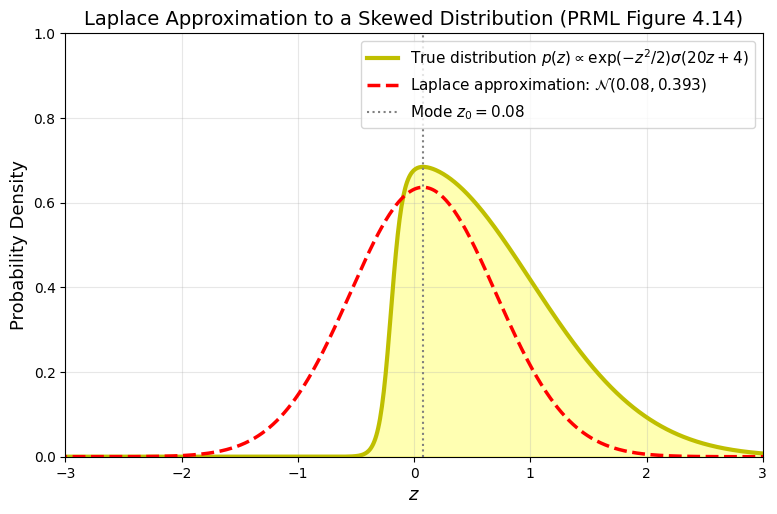

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.optimize as opt
import scipy.integrate as integrate
from common.plot_utils import save_plot, setup_style
from common.classification_utils import sigmoid
setup_style()

# PRML Figure 4.14 の完全再現: p(z) \propto exp(-z^2/2) * sigma(20z + 4)
def f_true(z):
    return np.exp(-0.5 * z**2) * sigmoid(20 * z + 4)

def neg_log_f(z):
    # -ln f(z) = 0.5 * z^2 - ln(sigma(20z + 4))
    return 0.5 * z**2 - np.log(sigmoid(20 * z + 4) + 1e-15)

# 最頻値 z0 の数値探索
res = opt.minimize_scalar(neg_log_f, bounds=(-2, 2), method='bounded')
z0 = res.x

# 2階微分 A = - d^2/dz^2 ln f(z)
eps = 1e-5
A = (neg_log_f(z0 + eps) - 2 * neg_log_f(z0) + neg_log_f(z0 - eps)) / (eps**2)
sigma_laplace = 1.0 / np.sqrt(A)

# 数値積分による真の規格化定数 Z_true
z_grid = np.linspace(-4, 4, 1000)
f_vals = f_true(z_grid)
Z_true = integrate.trapezoid(f_vals, z_grid)
p_true = f_vals / Z_true

# ラプラス近似ガウス分布 q(z)
q_laplace = stats.norm.pdf(z_grid, loc=z0, scale=sigma_laplace)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(z_grid, p_true, 'y-', lw=3, label=r'True distribution $p(z) \propto \exp(-z^2/2)\sigma(20z+4)$')
ax.fill_between(z_grid, 0, p_true, color='yellow', alpha=0.3)
ax.plot(z_grid, q_laplace, 'r--', lw=2.5, label=rf'Laplace approximation: $\mathcal{{N}}({z0:.2f}, {sigma_laplace**2:.3f})$')
ax.axvline(z0, color='gray', linestyle=':', label=rf'Mode $z_0 = {z0:.2f}$')

ax.set_title('Laplace Approximation to a Skewed Distribution (PRML Figure 4.14)', fontsize=14)
ax.set_xlabel('$z$', fontsize=13)
ax.set_ylabel('Probability Density', fontsize=13)
ax.set_xlim(-3, 3)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig4_14_laplace_approximation.png')
plt.show()

## 4.4.1 モデル比較と BIC (Bayesian Information Criterion)

ラプラス近似をモデルエビデンス（周辺尤度）$p(\mathcal{D}) = \int p(\mathcal{D}|\boldsymbol{\theta}) p(\boldsymbol{\theta}) d\boldsymbol{\theta}$ に適用すると：
$$ \ln p(\mathcal{D}) \simeq \ln p(\mathcal{D} | \boldsymbol{\theta}_{\mathrm{MAP}}) + \underbrace{\ln p(\boldsymbol{\theta}_{\mathrm{MAP}}) + \frac{M}{2} \ln(2\pi) - \frac{1}{2} \ln |\mathbf{A}|}_{\text{オッカム因子 (モデル複雑さペナルティ)}} $$
データ数 $N$ が非常に大きい極限（大標本近似）を考えると、ヘッセ行列は $\mathbf{A} \simeq N \mathbf{H}_0$ とスケールするため、$\ln |\mathbf{A}| \simeq M \ln N + \text{const}$ となります。
事前分布が一様であると見なすと、有名な**ベイズ情報量基準 (BIC)** が直ちに導かれます：
$$ \mathrm{BIC} = \ln p(\mathcal{D} | \boldsymbol{\theta}_{\mathrm{ML}}) - \frac{M}{2} \ln N $$
赤池情報量基準 (AIC: $\ln L - M$) と比較して、BIC はデータサイズ $N$ に依存する厳しいペナルティ $-\frac{M}{2}\ln N$ を課すため、過剰に複雑なモデルをより強く抑制します。

## 4.5 ベイズロジスティック回帰と予測分布 (PRML Figure 4.15)

### 1. パラメータ事後分布のラプラス近似
重み $\mathbf{w}$ の事前分布を等方ガウス分布 $p(\mathbf{w}) = \mathcal{N}(\mathbf{w} | \mathbf{0}, \alpha^{-1}\mathbf{I})$ とします。
MAP推定量 $\mathbf{w}_{\mathrm{MAP}}$ は L2 正則化付きロジスティック回帰によって得られ、その周りでの負の対数事後分布のヘッセ行列は
$$ \mathbf{S}_N^{-1} = -\nabla\nabla \ln p(\mathbf{w}|\mathbf{t}) = \alpha \mathbf{I} + \sum_{n=1}^N y_n (1 - y_n) \boldsymbol{\phi}_n \boldsymbol{\phi}_n^T = \alpha \mathbf{I} + \mathbf{\Phi}^T \mathbf{R} \mathbf{\Phi} $$
となります。したがって、事後分布のラプラス近似は $q(\mathbf{w}) = \mathcal{N}(\mathbf{w} | \mathbf{w}_{\mathrm{MAP}}, \mathbf{S}_N)$ です。

### 2. 予測分布の解析的導出
未知の入力 $\boldsymbol{\phi}$ に対するクラス $\mathcal{C}_1$ の事後確率は、$\mathbf{w}$ について周辺化します：
$$ p(\mathcal{C}_1 | \boldsymbol{\phi}, \mathbf{t}) = \int \sigma(\mathbf{w}^T \boldsymbol{\phi}) q(\mathbf{w}) d\mathbf{w} $$
一次元変数 $a = \mathbf{w}^T \boldsymbol{\phi}$ を定義すると、$q(\mathbf{w})$ がガウス分布であるため $a$ もガウス分布 $p(a) = \mathcal{N}(a | \mu_a, \sigma_a^2)$ に従います：
$$ \mu_a = \mathbf{w}_{\mathrm{MAP}}^T \boldsymbol{\phi}, \quad \sigma_a^2 = \boldsymbol{\phi}^T \mathbf{S}_N \boldsymbol{\phi} $$
積分 $\int \sigma(a) \mathcal{N}(a | \mu_a, \sigma_a^2) da$ は初等関数で表せませんが、プロビット近似 $\sigma(a) \approx \Phi(\lambda a)$ ($\lambda^2 = \pi/8$) を用いることで、ガウス畳み込みの解析解が得られます：
$$ p(\mathcal{C}_1 | \boldsymbol{\phi}, \mathbf{t}) \approx \sigma\left( \kappa(\sigma_a^2) \mu_a \right) $$
ここで
$$ \kappa(\sigma^2) = \left( 1 + \frac{\pi \sigma^2}{8} \right)^{-1/2} $$

### 不確実性による決定境界の「軟化」 (Softening of Decision Boundary)
- データ点が密集している領域: $\sigma_a^2 \to 0$ となり、$\kappa(\sigma_a^2) \to 1$。予測確率は通常のロジスティック回帰 $\sigma(\mu_a)$ と一致します。
- データ点から離れた未知の領域: パラメータの不確実性により $\sigma_a^2$ が巨大になり、**$\kappa(\sigma_a^2) \to 0$** となります。
  その結果、$\kappa(\sigma_a^2) \mu_a \to 0$ となり、$p(\mathcal{C}_1|\boldsymbol{\phi}, \mathbf{t}) \to \sigma(0) = 0.5$（**確信度 50%**）に漸近します！
  点推定（最尤推定やMAP）では未知の領域でも確信度 100% に過剰適合してしまうのに対し、**ベイズ推論は「自分が知らないこと」を正しく不確実性として表現できる**のです。

Plot saved to: result/fig4_15_bayesian_logistic_regression.png


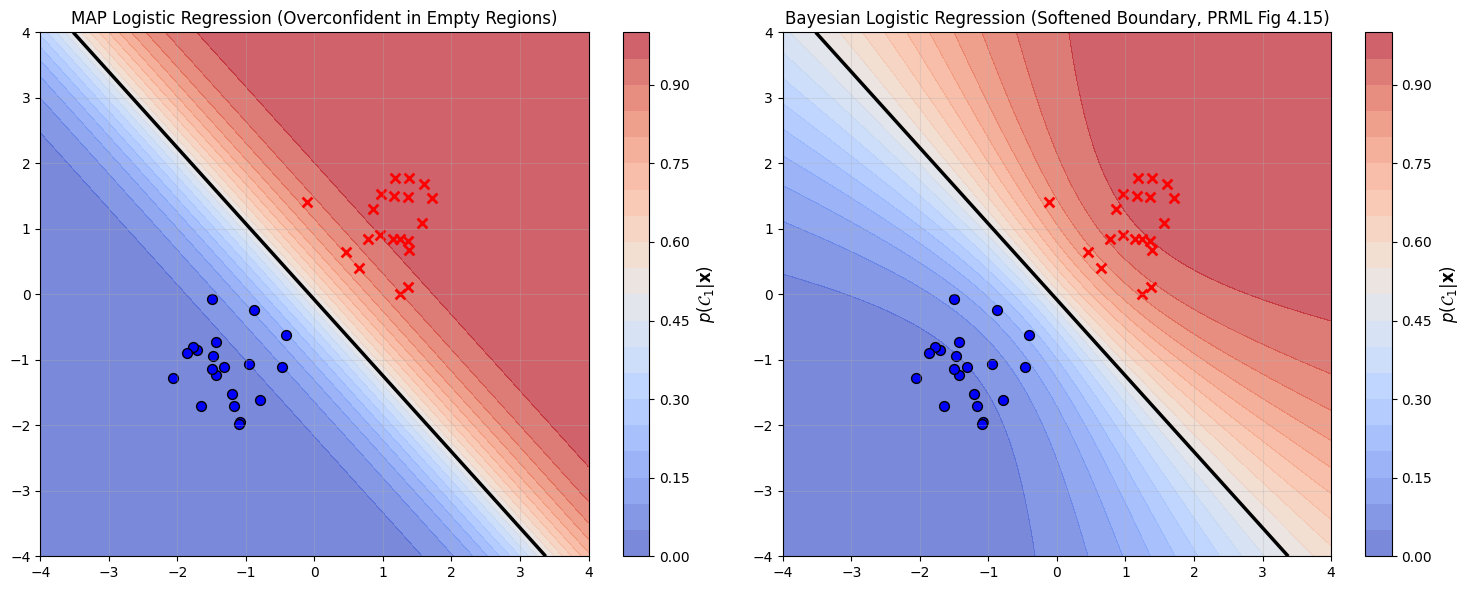

In [2]:
# PRML Figure 4.15 の再現: ベイズロジスティック回帰の予測確率と決定境界の軟化
from common.classification_utils import BayesianLogisticRegression, LogisticRegression

np.random.seed(42)

# 2クラスデータ (左下に密集)
N_sample = 20
X_b1 = np.random.randn(N_sample, 2) * 0.5 + np.array([-1.2, -1.0])
X_b2 = np.random.randn(N_sample, 2) * 0.5 + np.array([1.2, 1.0])
X_bayes = np.vstack([X_b1, X_b2])
y_bayes = np.array([0]*N_sample + [1]*N_sample)
Phi_bayes = np.column_stack([np.ones(len(X_bayes)), X_bayes])

# 1. 点推定 (MAP / 通常のロジスティック回帰)
lr_map = LogisticRegression(alpha=1.0).fit(Phi_bayes, y_bayes)

# 2. ベイズロジスティック回帰 (事後分布の不確実性を考慮)
blr = BayesianLogisticRegression(alpha=1.0).fit(Phi_bayes, y_bayes)

# 評価用グリッド
x_span = np.linspace(-4, 4, 150)
y_span = np.linspace(-4, 4, 150)
Xg, Yg = np.meshgrid(x_span, y_span)
grid_phi = np.column_stack([np.ones(len(Xg.ravel())), Xg.ravel(), Yg.ravel()])

prob_map = lr_map.predict_proba(grid_phi).reshape(Xg.shape)
prob_bayes = blr.predict_proba(grid_phi).reshape(Xg.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左: MAP推定 (硬い決定境界)
c0 = axes[0].contourf(Xg, Yg, prob_map, levels=20, cmap='coolwarm', alpha=0.7)
axes[0].contour(Xg, Yg, prob_map, levels=[0.5], colors='k', linewidths=2.5)
axes[0].scatter(X_b1[:, 0], X_b1[:, 1], c='b', marker='o', s=50, edgecolors='k')
axes[0].scatter(X_b2[:, 0], X_b2[:, 1], c='r', marker='x', s=50, lw=2)
fig.colorbar(c0, ax=axes[0], label=r'$p(\mathcal{C}_1|\mathbf{x})$')
axes[0].set_title('MAP Logistic Regression (Overconfident in Empty Regions)', fontsize=12)
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].grid(True, alpha=0.3)

# 右: ベイズ予測分布 (不確実性による境界の軟化 PRML Figure 4.15)
c1 = axes[1].contourf(Xg, Yg, prob_bayes, levels=20, cmap='coolwarm', alpha=0.7)
axes[1].contour(Xg, Yg, prob_bayes, levels=[0.5], colors='k', linewidths=2.5)
axes[1].scatter(X_b1[:, 0], X_b1[:, 1], c='b', marker='o', s=50, edgecolors='k')
axes[1].scatter(X_b2[:, 0], X_b2[:, 1], c='r', marker='x', s=50, lw=2)
fig.colorbar(c1, ax=axes[1], label=r'$p(\mathcal{C}_1|\mathbf{x})$')
axes[1].set_title('Bayesian Logistic Regression (Softened Boundary, PRML Fig 4.15)', fontsize=12)
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig4_15_bayesian_logistic_regression.png')
plt.show()